<a href="https://colab.research.google.com/github/baqueroxiomy-design/intro-ciencia-datos/blob/main/Regresi%C3%B3n_Lineal_TrabajoFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **REGRESIÓN LINEAL**

In [181]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler, PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor

df = pd.read_csv('//content/df (1).csv')
df

,area_construida_m2,m2_por_habitacion,banos,habitaciones,pisos,zona,anio_construccion,vista,precio
0,124.49002,41.5,1.50,3.0,1.5,Norte,1955,0,313000.00
1,339.09595,67.8,2.50,5.0,2.0,Seattle,1921,4,2384000.00
2,179.30279,59.8,2.00,3.0,1.0,Sur,1966,0,342000.00
3,185.80600,61.9,2.25,3.0,1.0,Eastside,1963,0,420000.00
4,180.23182,45.1,2.50,4.0,1.0,Eastside,1976,0,550000.00
...,...,...,...,...,...,...,...,...,...
4541,140.28353,46.8,1.75,3.0,1.0,Seattle,1954,0,308166.67
4542,135.63838,45.2,2.50,3.0,2.0,Eastside,1983,0,534333.33
4543,279.63803,93.2,2.50,3.0,2.0,Sur,2009,0,416904.17
4544,194.16727,48.5,2.00,4.0,1.0,Seattle,1974,0,203400.00


**EXPLORACIÓN**

In [182]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4546 entries, 0 to 4545
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   area_construida_m2  4546 non-null   float64
 1   m2_por_habitacion   4544 non-null   float64
 2   banos               4544 non-null   float64
 3   habitaciones        4544 non-null   float64
 4   pisos               4546 non-null   float64
 5   zona                4546 non-null   object 
 6   anio_construccion   4546 non-null   int64  
 7   vista               4546 non-null   int64  
 8   precio              4546 non-null   float64
dtypes: float64(6), int64(2), object(1)
memory usage: 319.8+ KB


In [183]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
area_construida_m2,4546.0,198.160219,88.816537,34.37411,135.63838,183.01891,242.47683,1.257907e+03
m2_por_habitacion,4544.0,58.266989,20.022756,15.20000,44.30000,54.30000,68.30000,1.988000e+02
banos,4544.0,2.156360,0.775357,0.75000,1.75000,2.25000,2.50000,8.000000e+00
habitaciones,4544.0,3.396347,0.902119,1.00000,3.00000,3.00000,4.00000,9.000000e+00
pisos,4546.0,1.512538,0.538565,1.00000,1.00000,1.50000,2.00000,3.500000e+00
anio_construccion,4546.0,1970.804883,29.769721,1900.00000,1951.00000,1976.00000,1997.00000,2.014000e+03
vista,4546.0,0.234932,0.765754,0.00000,0.00000,0.00000,0.00000,4.000000e+00
precio,4546.0,549328.793876,367385.109569,80000.00000,326446.42750,465000.00000,657400.00000,7.062500e+06


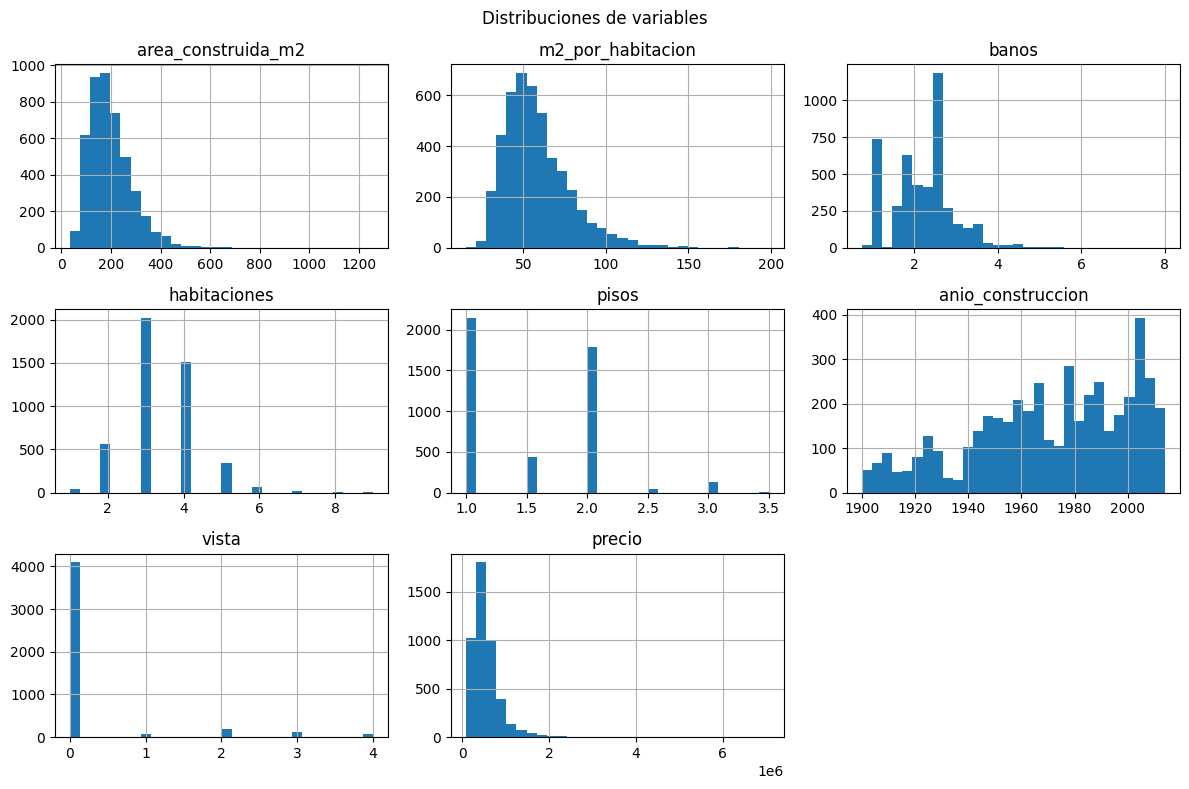

In [184]:
df[['area_construida_m2', 'm2_por_habitacion','banos','habitaciones', 'pisos', 'zona', 'anio_construccion', 'vista', 'precio']].hist(figsize=(12, 8), bins=30)
plt.suptitle('Distribuciones de variables')
plt.tight_layout()
plt.show()

**DEFINIR VARIABLES**

In [185]:
categoricas = ['zona',"vista"]
df['zona'] = df['zona'].astype('category')

df['vista'] =pd.Categorical(
    df['vista'],
    categories=[0, 1, 2, 3, 4],
    ordered=True
    )

In [186]:
X = df.drop(columns='precio')
y = df['precio']

num_cols = ['area_construida_m2', 'm2_por_habitacion', 'banos', 'habitaciones', 'pisos', 'anio_construccion' ]
nom_cols = ['zona']
ord_cols = ['vista']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
X_train.shape, X_test.shape

((3409, 8), (1137, 8))

# **PREPROCESADORES**

**StandardScaler**

In [187]:
num_mod = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

nom_mod = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'
    ))
])

ord_mod = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=[[0,1,2,3,4]]))
])

preprocess= ColumnTransformer(transformers=[
    ('num', num_mod , num_cols),
    ('nom', nom_mod, nom_cols),
    ('ord', ord_mod, ord_cols)
])

model_stand= Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LinearRegression())
])

model_stand.fit(X_train, y_train)
y_pred_test = model_stand.predict(X_test)

In [188]:
mae_stand = mean_absolute_error(y_test, y_pred_test)
mse_stand = mean_squared_error(y_test, y_pred_test)
rmse_stand = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_stand = r2_score(y_test, y_pred_test)

print('Métricas de StandardScaler')
print("MAE:", mae_stand)
print("MSE:", mse_stand)
print("RMSE:", rmse_stand)
print("R²:", r2_stand)

Métricas de StandardScaler
MAE: 130069.97574962759
MSE: 42375795767.592804
RMSE: 205853.82135776058
R²: 0.6075138925437578


**MinMaxScaler**

In [189]:
num_mod_minmax = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

preprocess_minmax = ColumnTransformer(transformers=[
    ('num', num_mod_minmax, num_cols),
    ('nom', nom_mod, nom_cols),
    ('ord', ord_mod, ord_cols)
])

model_minmax = Pipeline(steps=[
    ('preprocess', preprocess_minmax),
    ('model', LinearRegression())
])

model_minmax.fit(X_train, y_train)
y_pred_minmax = model_minmax.predict(X_test)

mae_minmax = mean_absolute_error(y_test, y_pred_minmax)
mse_minmax = mean_squared_error(y_test, y_pred_minmax)
rmse_minmax = np.sqrt(mse_minmax)
r2_minmax = r2_score(y_test, y_pred_minmax)

print('Métricas de MinMax')
print("MAE:", mae_minmax)
print("MSE:", mse_minmax)
print("RMSE:", rmse_minmax)
print("R²:", r2_minmax)

Métricas de MinMax
MAE: 130069.97574962759
MSE: 42375795767.59283
RMSE: 205853.82135776064
R²: 0.6075138925437575


**RobustScaler**

In [190]:
num_mod_robust = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

preprocess_robust = ColumnTransformer(transformers=[
    ('num', num_mod_robust, num_cols),
    ('nom', nom_mod, nom_cols),
    ('ord', ord_mod, ord_cols)
])

model_robust = Pipeline(steps=[
    ('preprocess', preprocess_robust),
    ('model', LinearRegression())
])

model_robust.fit(X_train, y_train)
y_pred_robust = model_robust.predict(X_test)

mae_robust = mean_absolute_error(y_test, y_pred_robust)
mse_robust = mean_squared_error(y_test, y_pred_robust)
rmse_robust = np.sqrt(mse_robust)
r2_robust = r2_score(y_test, y_pred_robust)

print('Métricas de Robust')
print("MAE:", mae_robust)
print("MSE:", mse_robust)
print("RMSE:", rmse_robust)
print("R²:", r2_robust)

Métricas de Robust
MAE: 130069.97574962761
MSE: 42375795767.59282
RMSE: 205853.8213577606
R²: 0.6075138925437575


**COMPARACIÓN DE LOS PREPROCESADORES**

In [191]:
comparacion_preprocesadores = pd.DataFrame({
    'Preprocesador': ['StandardScaler','MinMaxScaler','RobustScaler'],
    'MAE': [mae_stand, mae_minmax, mae_robust],
    'MSE': [mse_stand, mse_minmax, mse_robust],
    'RMSE': [rmse_stand, rmse_minmax, rmse_robust],
    'R²': [r2_stand, r2_minmax, r2_robust]
})


comparacion_preprocesadores

,Preprocesador,MAE,MSE,RMSE,R²
0,StandardScaler,130069.97575,4.237580e+10,205853.821358,0.607514
1,MinMaxScaler,130069.97575,4.237580e+10,205853.821358,0.607514
2,RobustScaler,130069.97575,4.237580e+10,205853.821358,0.607514


**¿CUAL ESCOGIMOS?**

Al comparar StandardScaler, MinMaxScaler y RobustScaler utilizando regresión lineal, se observa que las métricas obtenidas son prácticamente idénticas entre los tres preprocesadores. Esto indica que, para este modelo y conjunto de datos, el cambio de escala de las variables numéricas no produce una mejora significativa en el desempeño predictivo.
Debido a que los tres preprocesadores presentan un rendimiento equivalente, se selecciona StandardScaler como preprocesador final por ser una opción estándar y adecuada para normalizar las variables numéricas, manteniendo además un pipeline sencillo y consistente.

# **MODELO FINAL**

In [192]:
num_mod_final = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocess_final = ColumnTransformer(transformers=[
    ('num', num_mod_final, num_cols),
    ('nom', nom_mod, nom_cols),
    ('ord', ord_mod, ord_cols)
])

model_final = Pipeline(steps=[
    ('preprocess', preprocess_final),
    ('model', LinearRegression())
])

model_final.fit(X_train, y_train)
y_pred_final = model_final.predict(X_test)

**EVALUAMOS EL MODELO**

In [193]:
mae_final = mean_absolute_error(y_test, y_pred_test)
mse_final = mean_squared_error(y_test, y_pred_test)
rmse_final = np.sqrt(mse_final)
r2_final = r2_score(y_test, y_pred_test)

print("MAE:", mae_final)
print("MSE:", mse_final)
print("RMSE:", rmse_final)
print("R²:", r2_final)

MAE: 130069.97574962759
MSE: 42375795767.592804
RMSE: 205853.82135776058
R²: 0.6075138925437578


**COEFICIENTES**

In [194]:
coef_df = pd.DataFrame({
    'feature': model_final.named_steps['preprocess'].get_feature_names_out(),
    'coeficiente': model_final.named_steps['model'].coef_
}).sort_values('coeficiente', ascending=False).reset_index(drop=True)

coef_df

,feature,coeficiente
0,num__area_construida_m2,409485.819837
1,ord__vista,77022.413817
2,num__banos,31404.413276
3,num__pisos,18584.834431
4,nom__zona_Seattle,-24911.776773
5,num__anio_construccion,-60531.487857
6,num__m2_por_habitacion,-130590.778040
7,nom__zona_Norte,-133900.126047
8,num__habitaciones,-141076.650180
9,nom__zona_Rural,-188671.691214


Los coeficientes del modelo permiten analizar la relación estimada entre cada variable explicativa y el precio de la vivienda, manteniendo constantes las demás variables. Debido a que las variables numéricas fueron estandarizadas mediante StandardScaler, sus coeficientes representan el cambio esperado en el precio ante un aumento de una desviación estándar en la variable correspondiente.

La variable area_construida_m2 presenta el coeficiente positivo de mayor magnitud (409,485.82), por lo que un aumento de una desviación estándar en el área construida se asocia con un incremento estimado de aproximadamente 409,486 unidades monetarias en el precio, manteniendo constantes las demás variables.
banos (31,404.41) y pisos (18,584.83) presentan coeficientes positivos, aunque de menor magnitud. Por otro lado, m2_por_habitacion (−130,590.78), habitaciones (−141,076.65) y anio_construccion (−60,531.49) presentan coeficientes negativos. Estos resultados deben interpretarse como asociaciones dentro del modelo y no como relaciones causales.

Para la variable categórica zona, se tomó Eastside como categoría de referencia. En comparación con esta zona, los coeficientes estimados son negativos para Norte (−133,900.13), Rural (−188,671.69), Seattle (−24,911.78) y Sur (−240,780.98), manteniendo constantes las demás variables.
Finalmente, vista presenta un coeficiente positivo de 77,022.41, lo que indica que un incremento de un nivel en la escala ordinal de vista se asocia con un aumento estimado de aproximadamente 77,022 unidades monetarias en el precio, manteniendo constantes las demás variables.

En conjunto, area_construida_m2 destaca por presentar el coeficiente positivo de mayor magnitud, mientras que algunas variables relacionadas con las características de la vivienda y la zona presentan asociaciones negativas. Estos coeficientes permiten interpretar el comportamiento del modelo, pero no deben entenderse como efectos causales.

In [195]:
print('Intercepto: ', model_final.named_steps['model'].intercept_)

Intercepto:  619055.7017434149


**PREDICCIONES**

In [196]:
y_pred_train = model_final.predict(X_train)
y_pred_test = model_final.predict(X_test)

pred_df = pd.DataFrame({
    'precio_real': y_test.values,
    'precio_predicho': y_pred_test
})

pred_df.head(10)

,precio_real,precio_predicho
0,1225000.0,1.505285e+06
1,620000.0,6.151070e+05
2,612500.0,7.340507e+05
3,375000.0,4.133903e+05
4,615000.0,5.782977e+05
5,432000.0,3.686118e+05
6,265950.0,3.759413e+05
7,306000.0,4.068282e+05
8,530000.0,5.251352e+05
9,360000.0,3.440538e+05


**GRÁFICO REAL VS PREDICCIÓN**

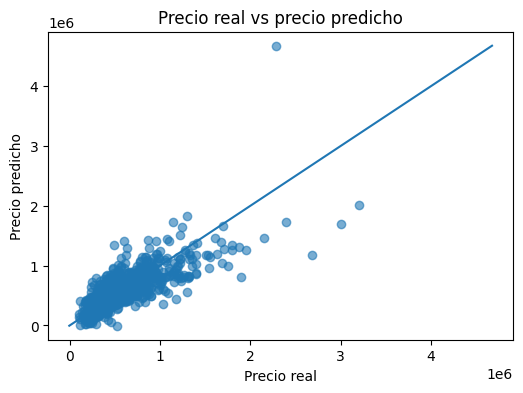

In [197]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred_test, alpha=0.6)
line_min = min(y_test.min(), y_pred_test.min())
line_max = max(y_test.max(), y_pred_test.max())
plt.plot([line_min, line_max], [line_min, line_max])
plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.title('Precio real vs precio predicho')
plt.show()

La gráfica muestra una relación positiva entre los precios reales y los precios predichos, lo que indica que el modelo logra capturar parcialmente la tendencia general del precio de las viviendas. Sin embargo, se observa una mayor dispersión en los precios altos y una tendencia del modelo a subestimar algunas viviendas de mayor valor. También se identifican algunos casos con errores de predicción elevados. Esto indica que la regresión lineal tiene dificultades para representar completamente los valores extremos del mercado.

**RESIDUALES**

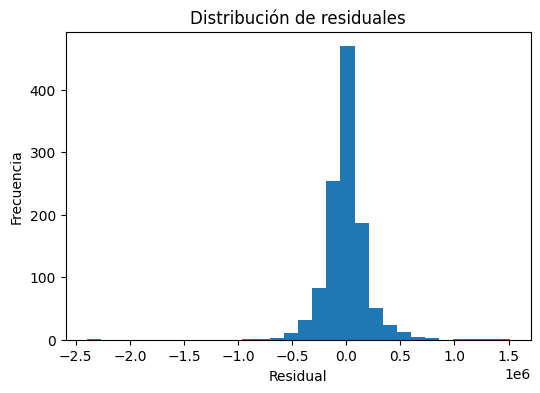

In [198]:
residuos = y_test - y_pred_test

plt.figure(figsize=(6, 4))
plt.hist(residuos, bins=30)
plt.title('Distribución de residuales')
plt.xlabel('Residual')
plt.ylabel('Frecuencia')
plt.show()

La mayoría de los residuos se concentra alrededor de cero, lo que indica que para una parte importante de las observaciones las predicciones se encuentran relativamente cerca de los valores reales. Sin embargo, se observan colas y algunos residuos extremos tanto positivos como negativos, lo que evidencia la presencia de errores de predicción elevados en determinadas viviendas. Esto sugiere que el modelo presenta mayores dificultades para representar algunos casos particulares, especialmente aquellos con precios extremos.

**Residuales vs Prediccion**

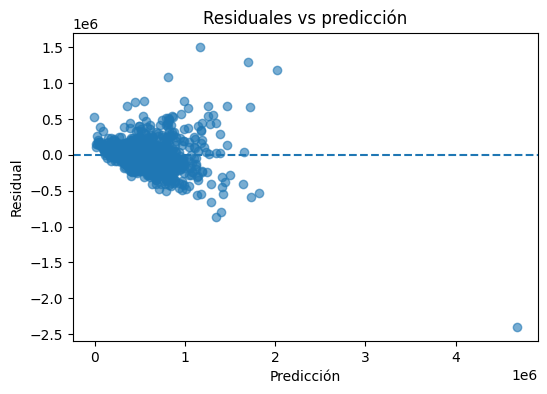

In [199]:
plt.figure(figsize=(6, 4))
plt.scatter(y_pred_test, residuos, alpha=0.6)
plt.axhline(0, linestyle='--')
plt.xlabel('Predicción')
plt.ylabel('Residual')
plt.title('Residuales vs predicción')
plt.show()

La gráfica muestra que los residuos se concentran alrededor de cero, principalmente en el rango de precios bajos y medios. Sin embargo, a medida que aumenta el precio predicho, también aumenta la dispersión de los residuos. Además, se identifican algunos valores extremos con errores elevados. Este comportamiento sugiere que la variabilidad de los errores no es constante a lo largo del rango de predicciones, lo que puede indicar la presencia de heterocedasticidad y una mayor dificultad del modelo para predecir correctamente las viviendas de mayor valor.

# **PREDICCIONES CON CASOS NUEVOS**

Para comprobar la aplicación práctica del modelo, se realizaron predicciones sobre tres viviendas hipotéticas utilizando las mismas variables empleadas durante el entrenamiento. El modelo permite estimar el precio de una vivienda a partir de sus características, aplicando automáticamente el preprocesamiento definido en el pipeline.

In [211]:
nuevas_viviendas = pd.DataFrame({
    'area_construida_m2': [60, 95, 140],
    'm2_por_habitacion': [30, 31.7, 35],
    'banos': [1, 2, 2],
    'habitaciones': [2, 3, 4],
    'pisos': [1, 2, 2],
    'zona': ['Sur', 'Seattle', 'Norte'],
    'anio_construccion': [2005, 2015, 2020],
    'vista': [1, 2, 3]
})

nuevas_viviendas['precio_estimado'] = model_final.predict(nuevas_viviendas)

nuevas_viviendas

,area_construida_m2,m2_por_habitacion,banos,habitaciones,pisos,zona,anio_construccion,vista,precio_estimado
0,60,30.0,1,2,1,Sur,2005,1,85279.187586
1,95,31.7,2,3,2,Seattle,2015,2,426660.552364
2,140,35.0,2,4,2,Norte,2020,3,413777.025556


Las predicciones realizadas para las tres nuevas viviendas muestran que el modelo puede utilizar las características de cada vivienda para obtener un precio estimado. Para los tres casos analizados, los precios obtenidos fueron 85.279,19, 426.660,55 y 413.777,03 unidades monetarias, respectivamente.
Los resultados muestran diferencias en los precios obtenidos según las características de cada vivienda. La segunda vivienda presentó el precio predicho más alto, mientras que la primera presentó el más bajo. La tercera vivienda, a pesar de contar con una mayor área construida y más habitaciones, presentó un precio inferior al de la segunda, debido a la combinación de todas las variables incluidas en el modelo.
En conjunto, estas predicciones muestran la aplicación del modelo desarrollado a nuevos casos y permiten observar cómo las características de las viviendas se reflejan en los precios obtenidos.

# **CONCLUSIONES**

El análisis permitió identificar las principales características relacionadas con el precio de las viviendas y desarrollar un modelo de Regresión Lineal capaz de predecir el precio a partir de variables como el área construida, número de habitaciones, baños, pisos, zona, año de construcción y vista.

Durante el análisis se encontró que el área construida tiene una relación especialmente importante con el precio. También se observaron diferencias importantes entre las zonas, lo que confirma que la ubicación tiene un papel relevante en el comportamiento de los precios. Estas relaciones también se reflejaron en los coeficientes obtenidos por el modelo.

El modelo final obtuvo un MAE de 130.069,98, un RMSE de 205.853,82 y un R² de 0,6075 en el conjunto de prueba. Estos resultados muestran que la Regresión Lineal logra capturar una parte importante del comportamiento del precio, aunque presenta mayores errores en algunas viviendas de precios elevados.

El análisis de residuos confirmó que la mayoría de los errores se concentra alrededor de cero, pero la dispersión aumenta a medida que aumenta el precio predicho. También se identificaron algunos errores extremos, lo que muestra una mayor dificultad del modelo para representar determinados valores altos.

Finalmente, las predicciones realizadas sobre nuevas viviendas demostraron la aplicación práctica del modelo, obteniendo diferentes precios de acuerdo con las características introducidas. En conjunto, el proyecto permitió pasar desde la exploración y preparación de los datos hasta la construcción, evaluación e interpretación de un modelo de predicción de precios.